## Recap
In the Stage2-trainingloop, we learned about loss calculation and training the model. The training loss vs validation loss, indicates that the model is sensitive to the training data. It means, the model predicts texts which are exact phrases from the book.

After Epoch-10, the model predicted the followings:

Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed luncheon-table, when, on a later day, I had again run over from Monte Carlo; and Mrs. Gis

But if you pickup a phrase from the output, you will see the text is a direct copy from the input book.

In order to add **creativity** to the LLM, We will learn about the decoding strategies in this chapter.

#### Code from Previous Chapter

In [1]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")

GPT2_SMALL_CONFIG = {
    "vocab_size": 50257,        # GPT-2 uses a tokenizer with vocab size of 50,257  (GPT-2 uses Byte Pair Encoder)
    "context_length": 256,      # context_length tells you how many tokens you pass in a sequence. also called sequence length. 
                                #It is 1024 for GPT-2. For simplicity, we use 256 here
    "emb_dim": 768,             # embedding dimension. the vector used by GPT-2 SMALL is of 768 dimension
    "n_heads": 12,              # number of heads in multi-head attention.
    "n_layers": 12,             # 12 number of transformer layers/blocks in gpt-2. Each transformer block has 12 multi-head attention.
    "drop_rate": 0.1,             # dropout rate is used to reduce overfitting
    "qkv_bias": False           # Query-Key-Value bias
}

######################################################################33
# Dataset and dataloader
class GPTDatasetV1(Dataset):
        """Small dataset: tokenize `txt` and yield overlapping (input, target).

        Parameters: `txt` (str), `tokenizer`, `max_length` (int), `stride` (int).
        """
        def __init__(self, txt, tokenizer, max_length, stride):
                self.input_ids = []
                self.target_ids = []

                # Tokenize the entire text
                token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

                # Use a sliding window to chunk the book into overlapping sequences of max_length
                for i in range(0, len(token_ids) - max_length, stride):
                        input_chunk = token_ids[i:i + max_length]
                        target_chunk = token_ids[i + 1: i + max_length + 1]
                        self.input_ids.append(torch.tensor(input_chunk))
                        self.target_ids.append(torch.tensor(target_chunk))

        def __len__(self):
                """Return the number of examples available."""
                return len(self.input_ids)

        def __getitem__(self, idx):
                """Return the (input_ids, target_ids) tuple for index `idx`.

                Both elements are 1-D `torch.Tensor` of token ids.
                """
                return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=False, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

__all__ = ["create_dataloader_v1", "GPTDatasetV1"]

##### Multi-head attention (produces context vector)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`,
        # this will result in errors in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.

        # print(f"Input Matrix: {x}\n")

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # print(f"Queries Weights: {self.W_query}\n")

        # print(f"Queries (after multiplying with weights. 6x3 matrix multiple with 3 x 2 matrix, produces 6 x 2 matrix): {queries}\n")


        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # print(f"Queries (after weight split): {queries.shape}\n")
        # print(f"Queries (after weight split): {queries}\n")

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec
##################################################################################################
# 
# LayerNorm (Layer Normalization) and GELU (Gaussian Error Linear Unit)    
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift
    
# Gaussian Error Linear Unit (GELU) activation function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))
# FeedForward (FFN) layer
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)
    
###################################################################################
### Transformer Block
### Transformer Block is a combination of MultiHeadAttention and FeedForward layers
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.dropout(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout(x)
        x = x + shortcut  # Add the original input back

        return x

##########################################################################
# GPT-2 model
# GPT-2 model is a stack of Transformer Blocks    
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # It stacks 12 transformer blocks together
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # print(f"Shape of the final normalization layer output: {self.final_norm.shape}\n")
        # print(f"the final normalization layer output: {self.final_norm}\n")
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        # embedding + psotional embedding takes place here
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]

        # dropout takes place
        x = self.drop_emb(x)

        # transformer blocks are invoked
        x = self.trf_blocks(x)

        # final normalization layer
        x = self.final_norm(x)

        # converts the output to logits which is probability distribution on the vocalbulary (50,257)
        logits = self.out_head(x)

        return logits

#########################################################################
# 
# Text generation
# This function generates text using a simple approach where it samples the next token based on the highest probability 
# It loops over the number of tokens to generate (max_new_tokens) and appends the sampled token to the current context (idx)
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

##############################################################################
# Loss calulating fucntions
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

###########################################################################################
# Evaluate the model on the training and validation datasets
# returns the average loss for the training and validation datasets
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

# train the model using the training data and validate it using the validation data
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

# predict using the trained model and print the generated text
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

#### Load the Weights from Previous Chapter Training

In [2]:
checkpoint = torch.load("./checkpoints/gpt2-pretrained.pth", weights_only=True)

model = GPTModel(GPT2_SMALL_CONFIG)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

#### Inferencing the Model

If you run the below code, you will see the LLM is generating the same output again and again. Also, the generated content is an exact copy of phrase from the book.

In [6]:
# NEW: use CPU here as inference is cheap with 
# this model and to ensure readers get same results in the
# remaining sections of this book
# inference_device = torch.device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

model = GPTModel(GPT2_SMALL_CONFIG)

model.to(device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=GPT2_SMALL_CONFIG["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren Mortgage TT remember gard ACTIONSussedOND Land Engeleddedemate breaths proxies GalaxyForm


## Decoding Strategies

The **Decoding Strategies** are used for bringing varities and creativity into the model. There are 2 techniques:

- Temperatur Scaling
- Top-K Sampling

![decode](https://camo.githubusercontent.com/fc5d290513e57d77770122795090dc2455d3791cfc4f836cbec591a42c392a05/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f31332e77656270)

### Temperature Scaling
In logits decoding, we use run argmax() over the output of softmax() and it returns the correct prediction. This token could be an exact copy from the source. There is no Generalization or Creativity.

- If I run the decoding 1000 times, argmax() is going to return me the same token all the 1000 times.

- Instead if I use multinomial() function, it may pick up any token which has probability more than 0. However, it may return the token with max probability maximum number of times. It gives highest weight to the token with highest probability.

Lets do a compare of argmax() and multinomial() by running the test 1000 times.

In [8]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

torch.manual_seed(123) # Manual seed for reproducibility

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)


#########################################################################3
## using argmax to get the next token
print("Using argmax:")
print("-"*50)
sample = [torch.argmax(probas).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

#########################################################################3
## using multinomial to get the next token
print("\nUsing multinomial:")
print("-"*50)
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

Using argmax:
--------------------------------------------------
0 x closer
0 x every
0 x effort
1000 x forward
0 x inches
0 x moves
0 x pizza
0 x toward
0 x you

Using multinomial:
--------------------------------------------------
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


**We can control this probability distribution by dividing logits by temperature scale.**

Let's try the multinomial again by using temperature scaling 0.2 and 0.7

In [9]:
temperature = 0.7

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
next_token_logits2 = next_token_logits / temperature

probas = torch.softmax(next_token_logits2, dim=0)

print("\nUsing multinomial with temperature scaling 0.7")
print("-"*50)
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")


Using multinomial with temperature scaling:
--------------------------------------------------
39 x closer
0 x every
0 x effort
633 x forward
0 x inches
0 x moves
0 x pizza
325 x toward
3 x you


In [13]:
temperature = 0.2

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
next_token_logits2 = next_token_logits / temperature

probas = torch.softmax(next_token_logits2, dim=0)

print("\nUsing multinomial with temperature scaling 0.2")
print("-"*50)
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")


Using multinomial with temperature scaling 0.2
--------------------------------------------------
0 x closer
0 x every
0 x effort
925 x forward
0 x inches
0 x moves
0 x pizza
75 x toward
0 x you


In [14]:
temperature = 0.001

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
next_token_logits2 = next_token_logits / temperature

probas = torch.softmax(next_token_logits2, dim=0)

print("\nUsing multinomial with temperature scaling 0.001")
print("-"*50)
sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")


Using multinomial with temperature scaling 0.001
--------------------------------------------------
0 x closer
0 x every
0 x effort
1000 x forward
0 x inches
0 x moves
0 x pizza
0 x toward
0 x you


**Notes**

As you can see above, increase in temperature increases randomness (or called creativitiy in llm language). But as you reduce the temperatur, the output of the llm becomes deterministic. A plot of various temperatur to demonstrate the same

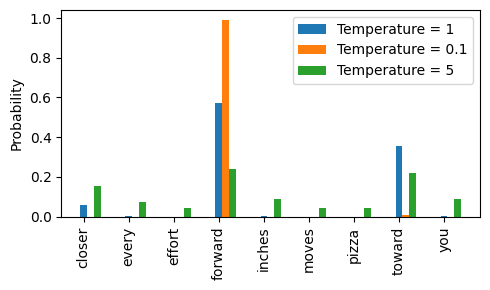

In [15]:
import matplotlib.pyplot as plt

def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

**Note**

At high temperature 5, you could see the randomness increases so much that it picks up the word "pizza" which has no relevance to "forward".

To address this issue, we will have to bring in top-k sampling.

### Top-k sampling

It works in conjuction with temperatur scaling. Top-k sampling is used to reduce the sample pick by multinomial() which helps in addressing the issue described above where the llm picked up unrelevant word.

You could see in the diagram, that top-k limits the tokens entering into the softmax() for probability calculation. It only picks up k number of tokens with highest weights.

![top-k](https://camo.githubusercontent.com/7bc113d7a12a49a473a9059f425850564ce392aa34d8925e6edeb0a9558b73cb/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f31352e77656270)



In [17]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


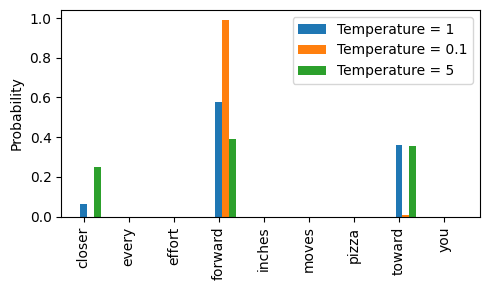

In [18]:
import matplotlib.pyplot as plt

def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(new_logits, T) for T in temperatures]

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

**Notes**

You could now see that pizza is no more a selection with high temperature.

## Summary
In this capture, we learned that token decoding shall consider the temperature scaling and top-k sampling. With that said, we will now replace our generate_text_simple() decode function with generate().

In [19]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values
            
            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [28]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT2_SMALL_CONFIG["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youEveryiliaralso stabbed OrleansAllowsean 52anche crime winter unbeaten quoteembedreportprint earning
